# ELMo Forward Pass (Didactic Simulation)

Uses library LSTM (PyTorch) and a character-level CNN

<br></br>
<be></br>

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

In [1]:
import torch
import torch.nn as nn
import pandas as pd

torch.manual_seed(42)

# STEP 1: Define a sentence and tokenise it

In [2]:
sentence = "I deposited money at the bank"
tokens = sentence.split()

print("STEP 1: Sentence and Tokens")
print("Sentence:", sentence)
print("Tokens:", tokens)

STEP 1: Sentence and Tokens
Sentence: I deposited money at the bank
Tokens: ['I', 'deposited', 'money', 'at', 'the', 'bank']


# STEP 2: Build character vocabulary

In [3]:
all_chars = sorted(set("".join(tokens)))
char_to_idx = {ch: i + 1 for i, ch in enumerate(all_chars)}   # reserve 0 for padding
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

print("STEP 2: Character Vocabulary")
print("Characters:", all_chars)
print("Vocabulary size (including padding):", len(char_to_idx) + 1)

STEP 2: Character Vocabulary
Characters: ['I', 'a', 'b', 'd', 'e', 'h', 'i', 'k', 'm', 'n', 'o', 'p', 's', 't', 'y']
Vocabulary size (including padding): 16


# STEP 3: Convert each token into character IDs

In [4]:
# Find max word length and corresponding token
max_word_len = max(len(token) for token in tokens)
longest_token = max(tokens, key=len)

def word_to_char_ids(word, char_to_idx, max_len):
    ids = [char_to_idx[ch] for ch in word]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids

char_id_matrix = torch.tensor(
    [word_to_char_ids(token, char_to_idx, max_word_len) for token in tokens],
    dtype=torch.long
)

print("STEP 3")
print("Max word length:", max_word_len)
print("Longest token  :", longest_token)
print()

print("Character ID Matrix:")
char_df = pd.DataFrame(char_id_matrix.numpy(), index=tokens)
print(char_df)

STEP 3
Max word length: 9
Longest token  : deposited

Character ID Matrix:
            0   1   2   3   4  5   6  7  8
I           1   0   0   0   0  0   0  0  0
deposited   4   5  12  11  13  7  14  5  4
money       9  11  10   5  15  0   0  0  0
at          2  14   0   0   0  0   0  0  0
the        14   6   5   0   0  0   0  0  0
bank        3   2  10   8   0  0   0  0  0


# STEP 4: Define the ELMo-like model

In [5]:
class DidacticELMo(nn.Module):
    def __init__(
        self,
        char_vocab_size,
        char_embed_dim=8,
        cnn_filters=16,
        cnn_kernel_size=3,
        lstm_hidden_size=12,
        num_lstm_layers=2
    ):
        super().__init__()

        # Character embedding layer
        self.char_embedding = nn.Embedding(
            num_embeddings=char_vocab_size,
            embedding_dim=char_embed_dim,
            padding_idx=0
        )

        # Character CNN
        self.char_cnn = nn.Conv1d(
            in_channels=char_embed_dim,
            out_channels=cnn_filters,
            kernel_size=cnn_kernel_size,
            padding=1
        )

        # First bidirectional LSTM
        self.bi_lstm_1 = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=lstm_hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # Second bidirectional LSTM
        self.bi_lstm_2 = nn.LSTM(
            input_size=2 * lstm_hidden_size,
            hidden_size=lstm_hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # Learnable scalar weights for ELMo combination
        self.layer_weights = nn.Parameter(torch.tensor([0.0, 0.0, 0.0]))

    def forward(self, char_ids):
        # ----------------------------------------------------
        # STEP 5: Character embeddings
        # Input shape: (num_tokens, max_word_len)
        # Output shape: (num_tokens, max_word_len, char_embed_dim)
        # ----------------------------------------------------
        char_embeds = self.char_embedding(char_ids)

        # ----------------------------------------------------
        # STEP 6: Apply character CNN
        # Conv1d expects (batch, channels, seq_len)
        # ----------------------------------------------------
        cnn_input = char_embeds.transpose(1, 2)
        cnn_output = self.char_cnn(cnn_input)

        # ----------------------------------------------------
        # STEP 7: Aggregate CNN features using max pooling
        # This creates one token representation per word
        # Output shape: (num_tokens, cnn_filters)
        # ----------------------------------------------------
        token_representations = torch.max(cnn_output, dim=2).values

        # ----------------------------------------------------
        # Prepare for sentence-level processing
        # Shape becomes: (1, seq_len, feature_dim)
        # ----------------------------------------------------
        sequence_input = token_representations.unsqueeze(0)

        # ----------------------------------------------------
        # STEP 8: First bidirectional LSTM
        # ----------------------------------------------------
        lstm1_output, _ = self.bi_lstm_1(sequence_input)

        # ----------------------------------------------------
        # STEP 9: Second bidirectional LSTM
        # ----------------------------------------------------
        lstm2_output, _ = self.bi_lstm_2(lstm1_output)

        # ----------------------------------------------------
        # STEP 10: Weighted combination of layers
        # ELMo-style weighted sum
        # ----------------------------------------------------
        normalized_weights = torch.softmax(self.layer_weights, dim=0)

        # To combine layers, token_representations must match LSTM dimensions
        # We project token_representations to the same dimension as LSTM outputs
        token_projection = torch.zeros_like(lstm1_output)
        token_projection[:, :, :token_representations.shape[1]] = sequence_input

        final_elmo = (
            normalized_weights[0] * token_projection +
            normalized_weights[1] * lstm1_output +
            normalized_weights[2] * lstm2_output
        )

        return {
            "char_embeds": char_embeds,
            "cnn_output": cnn_output,
            "token_representations": token_representations,
            "lstm1_output": lstm1_output,
            "lstm2_output": lstm2_output,
            "layer_weights": normalized_weights,
            "final_elmo": final_elmo
        }

# STEP 11: Create model

In [6]:
char_vocab_size = len(char_to_idx) + 1

model = DidacticELMo(
    char_vocab_size=char_vocab_size,
    char_embed_dim=8,
    cnn_filters=16,
    cnn_kernel_size=3,
    lstm_hidden_size=12,
    num_lstm_layers=2
)

print("STEP 11: Model Created")
print(model)

STEP 11: Model Created
DidacticELMo(
  (char_embedding): Embedding(16, 8, padding_idx=0)
  (char_cnn): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (bi_lstm_1): LSTM(16, 12, batch_first=True, bidirectional=True)
  (bi_lstm_2): LSTM(24, 12, batch_first=True, bidirectional=True)
)


# STEP 12: Run forward pass

In [7]:
outputs = model(char_id_matrix)

print("STEP 12: Forward Pass Completed")

STEP 12: Forward Pass Completed


# STEP 13: Inspect tensor shapes

In [8]:
print("STEP 13: Tensor Shapes")
print("Character embeddings shape       :", outputs["char_embeds"].shape)
print("CNN output shape                 :", outputs["cnn_output"].shape)
print("Token representation shape       :", outputs["token_representations"].shape)
print("First bi-LSTM output shape       :", outputs["lstm1_output"].shape)
print("Second bi-LSTM output shape      :", outputs["lstm2_output"].shape)
print("Final ELMo embedding shape       :", outputs["final_elmo"].shape)

STEP 13: Tensor Shapes
Character embeddings shape       : torch.Size([6, 9, 8])
CNN output shape                 : torch.Size([6, 16, 9])
Token representation shape       : torch.Size([6, 16])
First bi-LSTM output shape       : torch.Size([1, 6, 24])
Second bi-LSTM output shape      : torch.Size([1, 6, 24])
Final ELMo embedding shape       : torch.Size([1, 6, 24])


# STEP 14: Show normalised layer weights

In [9]:
print("STEP 14: Learned Layer Weights (Softmax-Normalised)")
print(outputs["layer_weights"].detach().numpy())

STEP 14: Learned Layer Weights (Softmax-Normalised)
[0.33333334 0.33333334 0.33333334]


# STEP 15: Show token representations after character CNN

In [10]:
print("STEP 15: Token Representations from Character CNN")
token_repr_df = pd.DataFrame(
    outputs["token_representations"].detach().numpy(),
    index=tokens
)
print(token_repr_df.T)

STEP 15: Token Representations from Character CNN
           I  deposited     money        at       the      bank
0   0.168098   0.615065  1.260133  0.201609  0.063533  0.720974
1   0.061042   0.633721  0.243864 -0.013805  0.914026  0.284064
2  -0.129158   0.464900  0.227972  0.098327  0.408809  0.625922
3   0.122637   1.112735  0.593979  0.450520  0.738773  0.432048
4   0.307519   0.552436  0.858121  0.568672  0.438946  0.726682
5  -0.193293   0.890133  0.581745  0.641607  0.264407 -0.158858
6   0.153984   0.242307  0.570021  0.381867  0.715974  0.609678
7   0.190698   0.641181  0.572988  0.547482  0.043182  0.350346
8   0.614861   0.954377  1.151947  0.116437  0.470202  0.131752
9   0.304275   1.173879  0.434486  0.601685  0.629401  0.284080
10  0.125550   1.262452  1.226979  0.549064  0.890096  0.396371
11  0.158635   0.259780  1.060269  0.312200  0.128017  1.129490
12  0.199798   0.587234  0.589782  0.398760  0.498460  0.335167
13  0.521443   0.192587  0.569018 -0.177223  0.547012 

The dimensionality of the token representation after the character CNN is determined by the number of convolutional filters. Each filter captures a distinct orthographic pattern, and after max pooling, contributes one scalar value to the final token representation.

# STEP 16: Show first bi-LSTM contextual representations

In [11]:
print("STEP 16: First bi-LSTM Output")
lstm1_df = pd.DataFrame(
    outputs["lstm1_output"].squeeze(0).detach().numpy(),
    index=tokens
)
print(lstm1_df.T)

STEP 16: First bi-LSTM Output
           I  deposited     money        at       the      bank
0  -0.015107   0.011971  0.009060  0.026583  0.029515  0.095174
1  -0.069565  -0.172967 -0.238193 -0.203458 -0.162103 -0.201264
2   0.004369  -0.002303 -0.037409 -0.056780 -0.055396 -0.107923
3  -0.100013  -0.101979 -0.147778 -0.120495 -0.116921 -0.261397
4   0.069792   0.115380  0.112037  0.204901  0.219566  0.220073
5  -0.110005  -0.161399 -0.202139 -0.205669 -0.158267 -0.160750
6  -0.140663  -0.294870 -0.303123 -0.249316 -0.346757 -0.271707
7  -0.021523  -0.166084 -0.056519 -0.100779 -0.169303 -0.031218
8   0.050090   0.171398  0.148894  0.138844  0.189458  0.129889
9   0.070162   0.065803  0.045907  0.057538  0.053207  0.093793
10 -0.102514  -0.276309 -0.447718 -0.439622 -0.488888 -0.556707
11  0.000197   0.097930  0.159568  0.196760  0.176456  0.243247
12  0.214546   0.268717  0.234531  0.172101  0.260225  0.155288
13 -0.214089  -0.201273 -0.216908 -0.152571 -0.144883 -0.134842
14 -0.2042

# STEP 17: Show second bi-LSTM contextual representations

In [12]:
print("STEP 17: Second bi-LSTM Output")
lstm2_df = pd.DataFrame(
    outputs["lstm2_output"].squeeze(0).detach().numpy(),
    index=tokens
)
print(lstm2_df.T)

STEP 17: Second bi-LSTM Output
           I  deposited     money        at       the      bank
0  -0.054676  -0.077756 -0.079901 -0.098583 -0.086779 -0.096083
1  -0.076670  -0.113594 -0.134205 -0.131308 -0.142875 -0.166676
2   0.064798   0.106009  0.133958  0.166932  0.175939  0.191487
3  -0.043752  -0.043985 -0.054718 -0.048731 -0.054248 -0.083387
4   0.150116   0.240715  0.296663  0.318873  0.328037  0.332029
5  -0.000593   0.010673  0.031769  0.043258  0.051940  0.078328
6  -0.022824  -0.034986 -0.041243 -0.064486 -0.051936 -0.057193
7   0.018585   0.020861  0.014393 -0.004049 -0.015038 -0.025830
8   0.093160   0.106664  0.083288  0.102038  0.106155  0.094262
9  -0.048584  -0.073759 -0.082773 -0.096464 -0.091911 -0.092294
10 -0.011996   0.008702  0.017833  0.007738  0.011037  0.001924
11  0.047502   0.081541  0.095749  0.108796  0.126923  0.123594
12  0.122119   0.114034  0.088389  0.084050  0.060327  0.015340
13 -0.151223  -0.154563 -0.157625 -0.152629 -0.139577 -0.086324
14 -0.101

# STEP 18: Show final ELMo embeddings

In [13]:
print("STEP 18: Final ELMo Embeddings")
final_elmo_df = pd.DataFrame(
    outputs["final_elmo"].squeeze(0).detach().numpy(),
    index=tokens
)
print(final_elmo_df.T)

STEP 18: Final ELMo Embeddings
           I  deposited     money        at       the      bank
0   0.032772   0.183093  0.396431  0.043203  0.002089  0.240022
1  -0.028398   0.115720 -0.042844 -0.116190  0.203016 -0.027959
2  -0.019997   0.189535  0.108174  0.069493  0.176451  0.236495
3  -0.007043   0.322257  0.130495  0.093765  0.189201  0.029088
4   0.175809   0.302844  0.422274  0.364148  0.328850  0.426261
5  -0.101297   0.246469  0.137125  0.159732  0.052693 -0.080427
6  -0.003168  -0.029183  0.075218  0.022689  0.105761  0.093593
7   0.062587   0.165319  0.176954  0.147551 -0.047053  0.097766
8   0.252704   0.410813  0.461376  0.119106  0.255272  0.118634
9   0.108618   0.388641  0.132540  0.187586  0.196899  0.095193
10  0.003680   0.331615  0.265698  0.039060  0.137415 -0.052804
11  0.068778   0.146417  0.438528  0.205919  0.143799  0.498777
12  0.178821   0.323328  0.304234  0.218303  0.273004  0.168598
13  0.052044  -0.054416  0.064828 -0.160808  0.087518  0.262455
14  0.129

# STEP 19: Example - Inspect one target token

In [14]:
target_token = "bank"
target_index = tokens.index(target_token)

print("STEP 19: Final Contextual Embedding for Target Token")
print("Target token:", target_token)
print("Embedding:")
print(outputs["final_elmo"].squeeze(0)[target_index].detach().numpy())

STEP 19: Final Contextual Embedding for Target Token
Target token: bank
Embedding:
[ 0.24002168 -0.02795858  0.23649527  0.029088    0.42626134 -0.08042687
  0.09359264  0.09776607  0.1186344   0.09519314 -0.05280392  0.4987774
  0.16859834  0.2624553   0.09686918  0.36966255 -0.05712535 -0.01536038
  0.02611338 -0.04027146  0.02034535  0.06358774  0.04262206  0.0290049 ]


In [15]:
# ------------------------------------------------------------
# STEP 20: Compact summary
# ------------------------------------------------------------
print("STEP 20: Summary")
print("1. Each token was converted into a sequence of characters.")
print("2. Characters were embedded into vectors.")
print("3. A CNN extracted local spelling patterns from characters.")
print("4. These token representations were passed through two bi-LSTM layers.")
print("5. The token representation, first bi-LSTM output, and second bi-LSTM output")
print("   were combined using learned scalar weights.")
print("6. The result is a contextual embedding for each token in the sentence.")

STEP 20: Summary
1. Each token was converted into a sequence of characters.
2. Characters were embedded into vectors.
3. A CNN extracted local spelling patterns from characters.
4. These token representations were passed through two bi-LSTM layers.
5. The token representation, first bi-LSTM output, and second bi-LSTM output
   were combined using learned scalar weights.
6. The result is a contextual embedding for each token in the sentence.


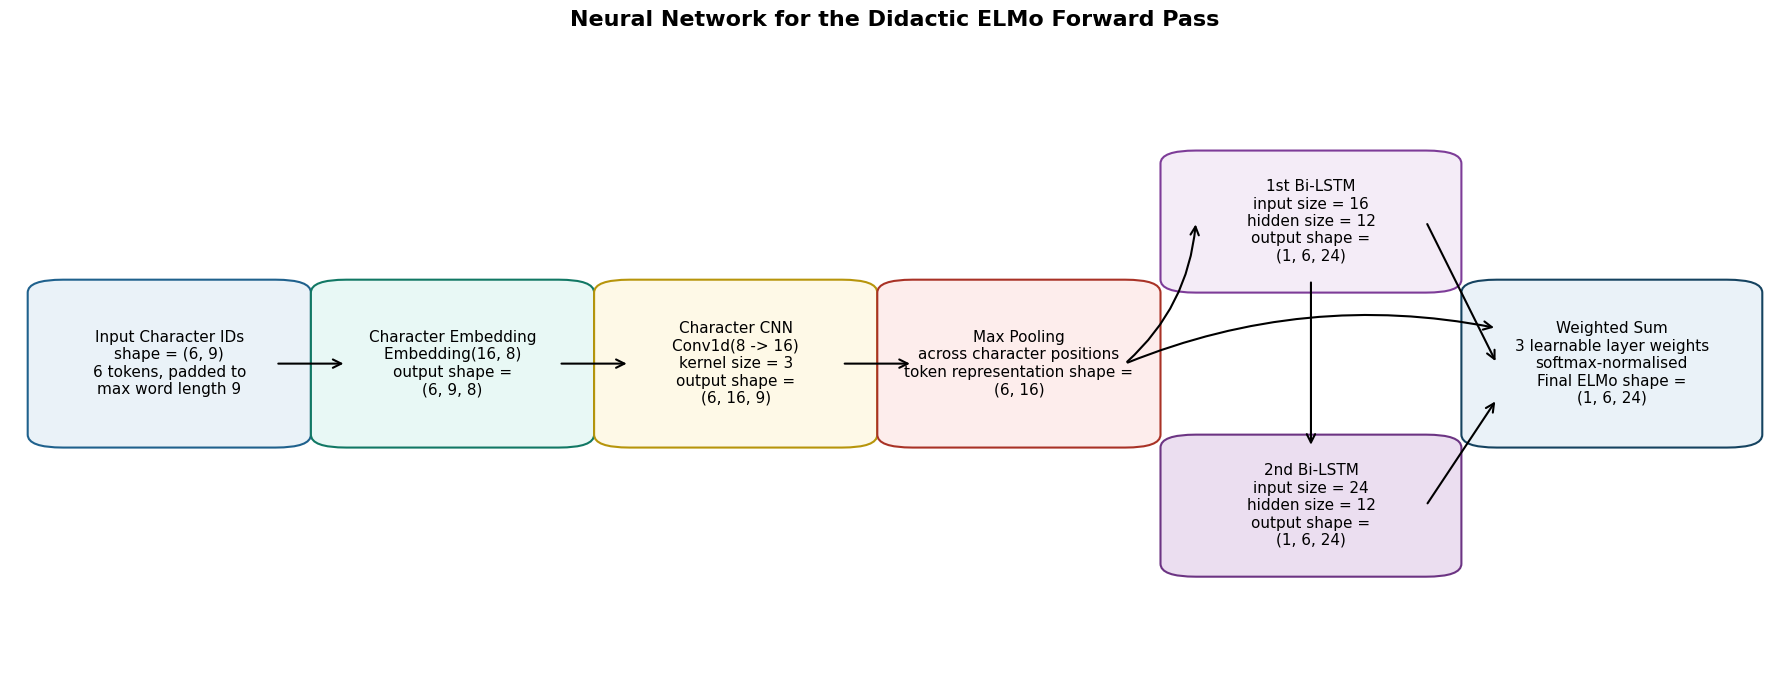

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ------------------------------------------------------------
# Draw Neural Network for the Didactic ELMo Forward Pass
# Uses existing variables from your notebook:
# tokens, max_word_len, char_vocab_size, model, outputs
# ------------------------------------------------------------

# Read dimensions directly from variables / model / outputs
num_tokens = len(tokens)
char_embed_dim = model.char_embedding.embedding_dim
cnn_filters = model.char_cnn.out_channels
cnn_kernel_size = model.char_cnn.kernel_size[0]
lstm1_hidden_size = model.bi_lstm_1.hidden_size
lstm2_hidden_size = model.bi_lstm_2.hidden_size
lstm1_output_dim = outputs["lstm1_output"].shape[-1]
lstm2_output_dim = outputs["lstm2_output"].shape[-1]
final_elmo_dim = outputs["final_elmo"].shape[-1]
num_layer_weights = outputs["layer_weights"].shape[0]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def add_box(ax, x, y, w, h, text, fontsize=11, fc="#EAF2F8", ec="#1F618D"):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.5, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)
    ax.text(
        x + w/2, y + h/2, text,
        ha="center", va="center",
        fontsize=fontsize, family="sans-serif"
    )
    return box

def connect(ax, box1, box2):
    x1 = box1.get_x() + box1.get_width()
    y1 = box1.get_y() + box1.get_height() / 2
    x2 = box2.get_x()
    y2 = box2.get_y() + box2.get_height() / 2
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->", mutation_scale=15,
        linewidth=1.5, color="black"
    )
    ax.add_patch(arrow)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# ------------------------------------------------------------
# Boxes
# ------------------------------------------------------------
box1 = add_box(
    ax, 0.03, 0.38, 0.12, 0.22,
    f"Input Character IDs\n"
    f"shape = ({num_tokens}, {max_word_len})\n"
    f"{num_tokens} tokens, padded to\n"
    f"max word length {max_word_len}"
)

box2 = add_box(
    ax, 0.19, 0.38, 0.12, 0.22,
    f"Character Embedding\n"
    f"Embedding({char_vocab_size}, {char_embed_dim})\n"
    f"output shape =\n"
    f"({num_tokens}, {max_word_len}, {char_embed_dim})",
    fc="#E8F8F5", ec="#117864"
)

box3 = add_box(
    ax, 0.35, 0.38, 0.12, 0.22,
    f"Character CNN\n"
    f"Conv1d({char_embed_dim} -> {cnn_filters})\n"
    f"kernel size = {cnn_kernel_size}\n"
    f"output shape =\n"
    f"({num_tokens}, {cnn_filters}, {max_word_len})",
    fc="#FEF9E7", ec="#B7950B"
)

box4 = add_box(
    ax, 0.51, 0.38, 0.12, 0.22,
    f"Max Pooling\n"
    f"across character positions\n"
    f"token representation shape =\n"
    f"({num_tokens}, {cnn_filters})",
    fc="#FDEDEC", ec="#A93226"
)

box5 = add_box(
    ax, 0.67, 0.62, 0.13, 0.18,
    f"1st Bi-LSTM\n"
    f"input size = {cnn_filters}\n"
    f"hidden size = {lstm1_hidden_size}\n"
    f"output shape =\n"
    f"(1, {num_tokens}, {lstm1_output_dim})",
    fc="#F4ECF7", ec="#7D3C98"
)

box6 = add_box(
    ax, 0.67, 0.18, 0.13, 0.18,
    f"2nd Bi-LSTM\n"
    f"input size = {lstm1_output_dim}\n"
    f"hidden size = {lstm2_hidden_size}\n"
    f"output shape =\n"
    f"(1, {num_tokens}, {lstm2_output_dim})",
    fc="#EBDEF0", ec="#6C3483"
)

box7 = add_box(
    ax, 0.84, 0.38, 0.13, 0.22,
    f"Weighted Sum\n"
    f"{num_layer_weights} learnable layer weights\n"
    f"softmax-normalised\n"
    f"Final ELMo shape =\n"
    f"(1, {num_tokens}, {final_elmo_dim})",
    fc="#EAF2F8", ec="#154360"
)

# ------------------------------------------------------------
# Connections
# ------------------------------------------------------------
connect(ax, box1, box2)
connect(ax, box2, box3)
connect(ax, box3, box4)

# Branch from token representation to first Bi-LSTM
arrow_up = FancyArrowPatch(
    (box4.get_x() + box4.get_width(), box4.get_y() + box4.get_height()/2),
    (box5.get_x(), box5.get_y() + box5.get_height()/2),
    connectionstyle="arc3,rad=0.2",
    arrowstyle="->", mutation_scale=15,
    linewidth=1.5, color="black"
)
ax.add_patch(arrow_up)

# First Bi-LSTM to second Bi-LSTM
arrow_down = FancyArrowPatch(
    (box5.get_x() + box5.get_width()/2, box5.get_y()),
    (box6.get_x() + box6.get_width()/2, box6.get_y() + box6.get_height()),
    arrowstyle="->", mutation_scale=15,
    linewidth=1.5, color="black"
)
ax.add_patch(arrow_down)

# Token projection branch to weighted sum
arrow_proj = FancyArrowPatch(
    (box4.get_x() + box4.get_width(), box4.get_y() + box4.get_height()/2),
    (box7.get_x(), box7.get_y() + box7.get_height()*0.75),
    connectionstyle="arc3,rad=-0.15",
    arrowstyle="->", mutation_scale=15,
    linewidth=1.5, color="black"
)
ax.add_patch(arrow_proj)

# 1st Bi-LSTM to weighted sum
arrow_lstm1 = FancyArrowPatch(
    (box5.get_x() + box5.get_width(), box5.get_y() + box5.get_height()/2),
    (box7.get_x(), box7.get_y() + box7.get_height()/2),
    arrowstyle="->", mutation_scale=15,
    linewidth=1.5, color="black"
)
ax.add_patch(arrow_lstm1)

# 2nd Bi-LSTM to weighted sum
arrow_lstm2 = FancyArrowPatch(
    (box6.get_x() + box6.get_width(), box6.get_y() + box6.get_height()/2),
    (box7.get_x(), box7.get_y() + box7.get_height()*0.25),
    arrowstyle="->", mutation_scale=15,
    linewidth=1.5, color="black"
)
ax.add_patch(arrow_lstm2)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------
plt.title("Neural Network for the Didactic ELMo Forward Pass", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()